# Import Libraries

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,SimpleRNN,LSTM,GRU,Dropout,Input
import warnings
warnings.filterwarnings('ignore')


# Load Dataset

In [ ]:
df = pd.read_csv("ai_financial_market_daily_realistic_synthetic.csv", delimiter=',')


#Pandas operations
print("df.head() :", df.head(5))
print("df.info() :", df.info())
print("df.describe() :", df.describe())
print("df.columns :", df.columns)
print(df.isnull().sum())


df.head() :          Date Company  R&D_Spending_USD_Mn  AI_Revenue_USD_Mn  \
0  2015-01-01  OpenAI                 5.92               0.63   
1  2015-01-02  OpenAI                 5.41               1.81   
2  2015-01-03  OpenAI                 4.50               0.61   
3  2015-01-04  OpenAI                 5.45               0.95   
4  2015-01-05  OpenAI                 3.40               1.48   

   AI_Revenue_Growth_% Event  Stock_Impact_%  
0               -36.82   NaN           -0.36  
1                80.59   NaN            0.41  
2               -38.88   NaN            0.23  
3                -5.34   NaN            0.93  
4                48.45   NaN           -0.09  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 10959 non-null  object 
 1   Company              10959 non-null  object 
 2   R&

# Data Preprocessing

In [39]:
# Convert Date column to datetime

df['Date'] = pd.to_datetime(df['Date'])

# Sort dataset according to date

df = df.sort_values('Date')

# Check missing values

print(df.isnull().sum())

# Fill missing Event values

df['Event'] = df['Event'].fillna('No_Event')

# Display statistical summary

print(df.describe())

Date                       0
Company                    0
R&D_Spending_USD_Mn        0
AI_Revenue_USD_Mn          0
AI_Revenue_Growth_%        0
Event                  10726
Stock_Impact_%             0
dtype: int64
                                Date  R&D_Spending_USD_Mn  AI_Revenue_USD_Mn  \
count                          10959         10959.000000       10959.000000   
mean   2019-12-31 23:59:59.999999744            65.184504          44.126571   
min              2015-01-01 00:00:00             1.570000          -0.550000   
25%              2017-07-02 00:00:00             8.640000           3.610000   
50%              2020-01-01 00:00:00            70.960000          35.220000   
75%              2022-07-02 00:00:00            99.600000          71.680000   
max              2024-12-31 00:00:00           163.830000         155.960000   
std                              NaN            47.918247          41.639356   

       AI_Revenue_Growth_%  Stock_Impact_%  
count         1095

# Numpy Operations

In [40]:
revenue_array = np.array(df['AI_Revenue_USD_Mn'])

print("Mean Revenue:", np.mean(revenue_array))
print("Maximum Revenue:", np.max(revenue_array))
print("Minimum Revenue:", np.min(revenue_array))
print("Standard Deviation:", np.std(revenue_array))

Mean Revenue: 44.12657085500502
Maximum Revenue: 155.96
Minimum Revenue: -0.55
Standard Deviation: 41.63745626417608


# Seaborn Graphs

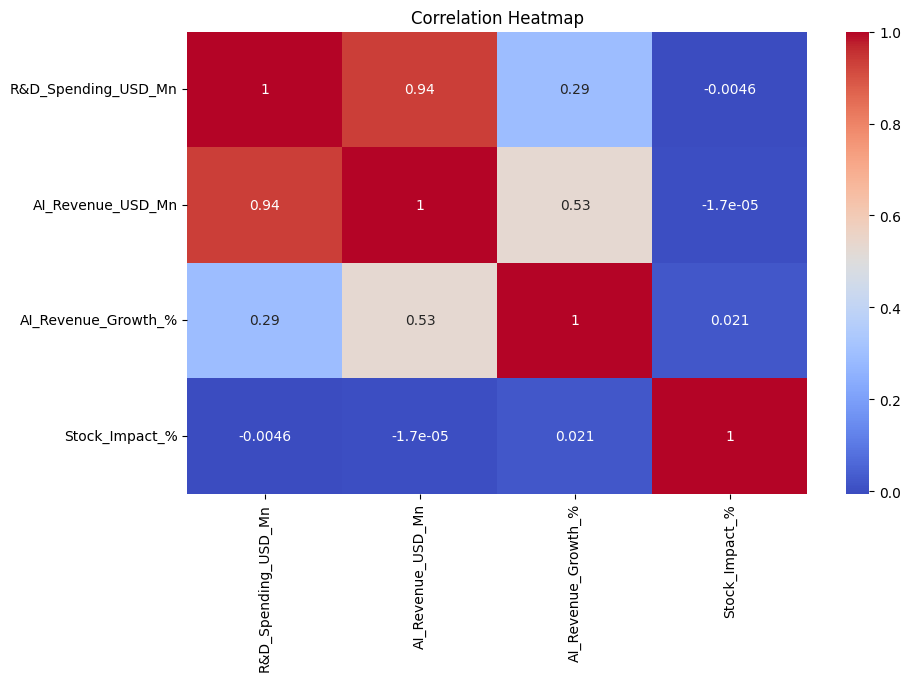

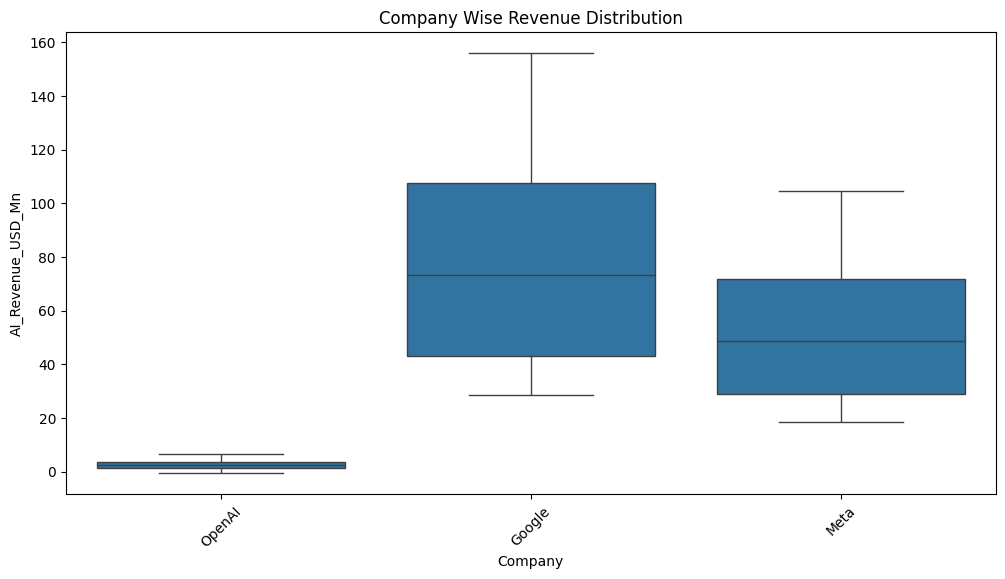

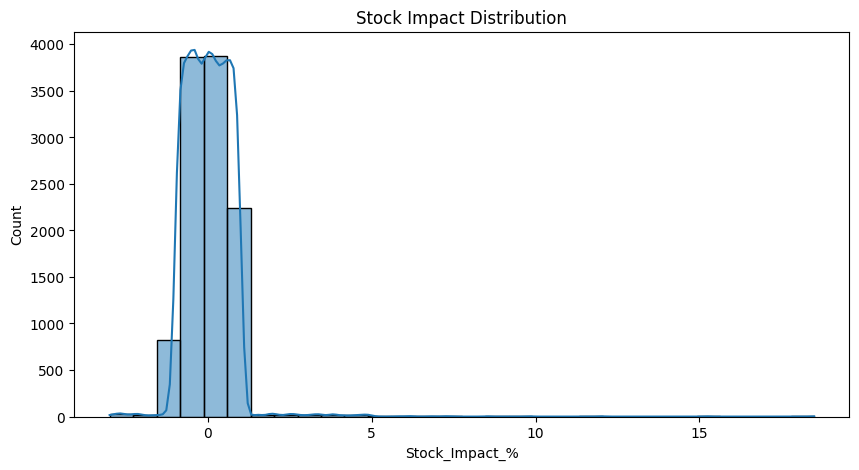

In [41]:
#heatmap to check the corrrelation
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()


# boxplot for company wise analysis

plt.figure(figsize=(12,6))

sns.boxplot(x='Company',
            y='AI_Revenue_USD_Mn',
            data=df)

plt.xticks(rotation=45)
plt.title('Company Wise Revenue Distribution')
plt.show()

# histplot for stock impact distributiom

plt.figure(figsize=(10,5))

sns.histplot(df['Stock_Impact_%'],
             bins=30,
             kde=True)

plt.title('Stock Impact Distribution')
plt.show()


# Feature Selection for Time Series

In [42]:
# we will predict AI Revenue
data = df[['AI_Revenue_USD_Mn']]

print(data.head())

      AI_Revenue_USD_Mn
0                  0.63
3653              30.19
7306              18.95
1                  1.81
3654              30.44


# Data Scaling

In [43]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

print(scaled_data[:5])

revenue_scaler = MinMaxScaler()
revenue_scaler.fit_transform(df[['AI_Revenue_USD_Mn']])

[[0.00753945]
 [0.19640918]
 [0.12459268]
 [0.01507891]
 [0.19800652]]


array([[0.00753945],
       [0.19640918],
       [0.12459268],
       ...,
       [0.99239665],
       [0.03494984],
       [0.66423871]], shape=(10959, 1))

# Create Time Series Sequences

In [ ]:
X = []
y = []

sequence_length = 60

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(10899, 60)
(10899,)


# Reshape Input Data for Deep Learning

In [45]:

X = np.reshape(X, (X.shape[0], X.shape[1], 1))
print(X.shape)

(10899, 60, 1)


# Train Test Split Function

In [46]:
# I have taken 80% training and 20% testing data

split = int(0.80 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(8719, 60, 1)
(2180, 60, 1)


# Simple RNN Model

In [47]:
rnn_model = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    SimpleRNN(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

rnn_model.compile(optimizer='adam',
                  loss='mean_squared_error')

rnn_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

# Train RNN Model

In [48]:
rnn_history = rnn_model.fit(X_train,
                            y_train,
                            epochs=50,
                            batch_size=32,
                            validation_data=(X_test,y_test))

Epoch 1/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0232 - val_loss: 0.0935
Epoch 2/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0159 - val_loss: 0.0913
Epoch 3/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0156 - val_loss: 0.1030
Epoch 4/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.0148 - val_loss: 0.0865
Epoch 5/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0148 - val_loss: 0.1245
Epoch 6/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.0143 - val_loss: 0.0994
Epoch 7/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0142 - val_loss: 0.1153
Epoch 8/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 0.0142 - val_loss: 0.1317
Epoch 9/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0139 - val_loss: 0.1086
Epoch 10/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0140 - val_loss: 0.1098
Epoch 11/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0135 - val_loss: 0.1341
Epoch 12/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 

# LSTM MODEL

In [49]:
lstm_model = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(units=64, return_sequences=True),
    Dropout(0.2),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam',
                   loss='mean_squared_error')

lstm_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

# TRAIN LSTM MODEL

In [50]:
lstm_history = lstm_model.fit(X_train,
                              y_train,
                              epochs=50,
                              batch_size=32,
                              validation_data=(X_test,y_test))

Epoch 1/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - loss: 0.0321 - val_loss: 0.1322
Epoch 2/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 18s 67ms/step - loss: 0.0289 - val_loss: 0.1267
Epoch 3/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - loss: 0.0252 - val_loss: 0.1099
Epoch 4/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - loss: 0.0225 - val_loss: 0.1042
Epoch 5/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - loss: 0.0212 - val_loss: 0.0947
Epoch 6/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - loss: 0.0202 - val_loss: 0.0971
Epoch 7/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - loss: 0.0199 - val_loss: 0.0903
Epoch 8/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - loss: 0.0191 - val_loss: 0.1284
Epoch 9/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - loss: 0.0194 - val_loss: 0.0908
Epoch 10/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 18s 67ms/step - loss: 0.0184 - val_loss: 0.1203
Epoch 11/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - loss: 0.0180 - val_loss: 0.0832
Epoch 12/50
273/273 ━━━━━━━━━━

# GRU MODEL

In [51]:
gru_model = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    GRU(units=64, return_sequences=True),
    Dropout(0.2),
    GRU(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(optimizer='adam',
                  loss='mean_squared_error')

gru_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 60, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,305 (87.13 KB)

 Trainable params: 22,305 (87.13 KB)

 Non-trainable params: 0 (0.00 B)

# TRAIN GRU MODEL

In [52]:
gru_history = gru_model.fit(X_train,
                            y_train,
                            epochs=50,
                            batch_size=32,
                            validation_data=(X_test,y_test))

Epoch 1/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 28s 77ms/step - loss: 0.0300 - val_loss: 0.1033
Epoch 2/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - loss: 0.0237 - val_loss: 0.0919
Epoch 3/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - loss: 0.0218 - val_loss: 0.0876
Epoch 4/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - loss: 0.0208 - val_loss: 0.0931
Epoch 5/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 24s 87ms/step - loss: 0.0198 - val_loss: 0.1418
Epoch 6/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 20s 74ms/step - loss: 0.0189 - val_loss: 0.0962
Epoch 7/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - loss: 0.0185 - val_loss: 0.0937
Epoch 8/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 21s 77ms/step - loss: 0.0178 - val_loss: 0.0857
Epoch 9/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 22s 78ms/step - loss: 0.0177 - val_loss: 0.0884
Epoch 10/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - loss: 0.0168 - val_loss: 0.0910
Epoch 11/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 20s 74ms/step - loss: 0.0166 - val_loss: 0.0906
Epoch 12/50
273/273 ━━━━━━━━━━

# Model predictions

In [53]:
rnn_pred = rnn_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

# Inverse Transform

rnn_pred = scaler.inverse_transform(rnn_pred)
lstm_pred = scaler.inverse_transform(lstm_pred)
gru_pred = scaler.inverse_transform(gru_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))


69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step


# Eualuation Function

In [54]:
def evaluate_model(actual, predicted, model_name):

    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)

    print(f'\n{model_name} Performance')
    print('-----------------------')
    print('MAE  :', mae)
    print('MSE  :', mse)
    print('RMSE :', rmse)
    print('R2 Score :', r2)

# Evaluate Models

evaluate_model(y_test_actual, rnn_pred, 'Simple RNN')
evaluate_model(y_test_actual, lstm_pred, 'LSTM')
evaluate_model(y_test_actual, gru_pred, 'GRU')


Simple RNN Performance
-----------------------
MAE  : 47.54572472675883
MSE  : 3010.5018896273596
RMSE : 54.868040694263534
R2 Score : 0.09382582555268881

LSTM Performance
-----------------------
MAE  : 41.26805969599803
MSE  : 2477.4312210188614
RMSE : 49.77380054826898
R2 Score : 0.2542824174295252

GRU Performance
-----------------------
MAE  : 31.05964269445966
MSE  : 1687.4053798033065
RMSE : 41.07804011638465
R2 Score : 0.49208363486844275


# Seaborn Visual Graphs Comparison

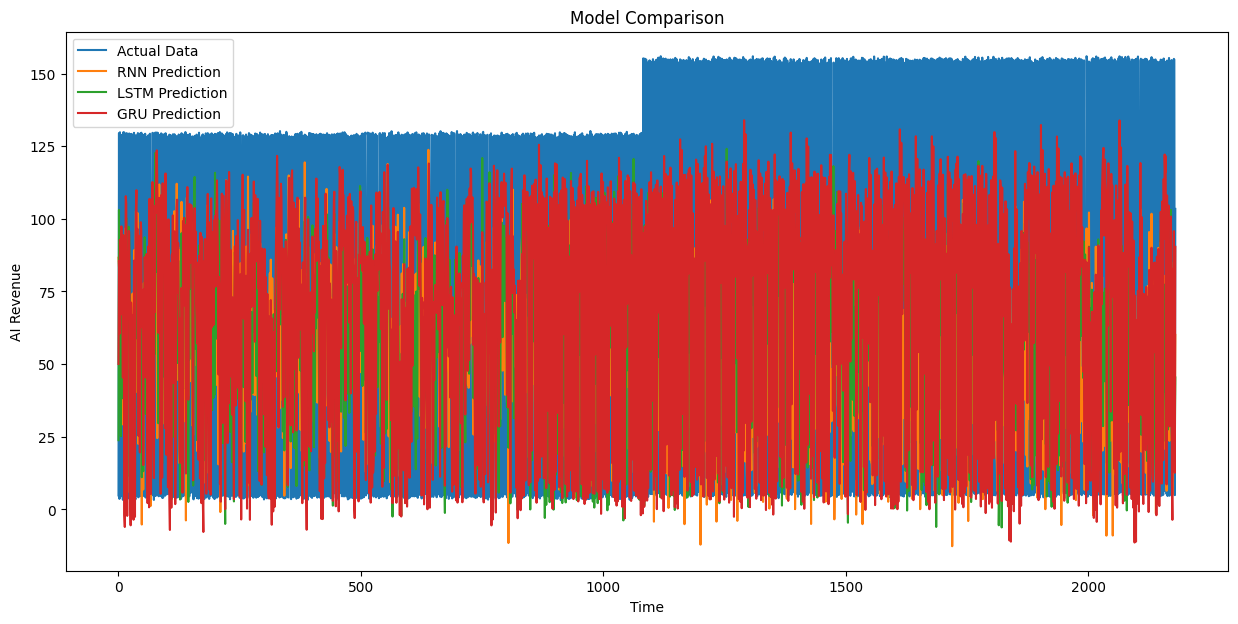

In [55]:
plt.figure(figsize=(15,7))

plt.plot(y_test_actual,
         label='Actual Data')

plt.plot(rnn_pred,
         label='RNN Prediction')

plt.plot(lstm_pred,
         label='LSTM Prediction')

plt.plot(gru_pred,
         label='GRU Prediction')

plt.title('Model Comparison')
plt.xlabel('Time')
plt.ylabel('AI Revenue')
plt.legend()
plt.show()

# Training Loss Analysis Graph

Text(0.5, 1.0, 'GRU Training vs Validation Loss')

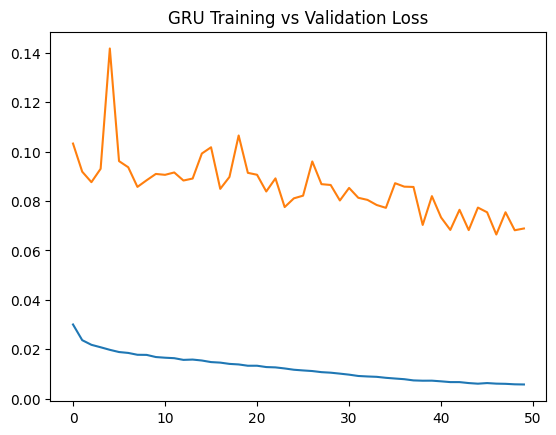

In [58]:
plt.plot(gru_history.history['loss'],
         label='Training Loss')

plt.plot(gru_history.history['val_loss'],
         label='Validation Loss')

plt.title('GRU Training vs Validation Loss')

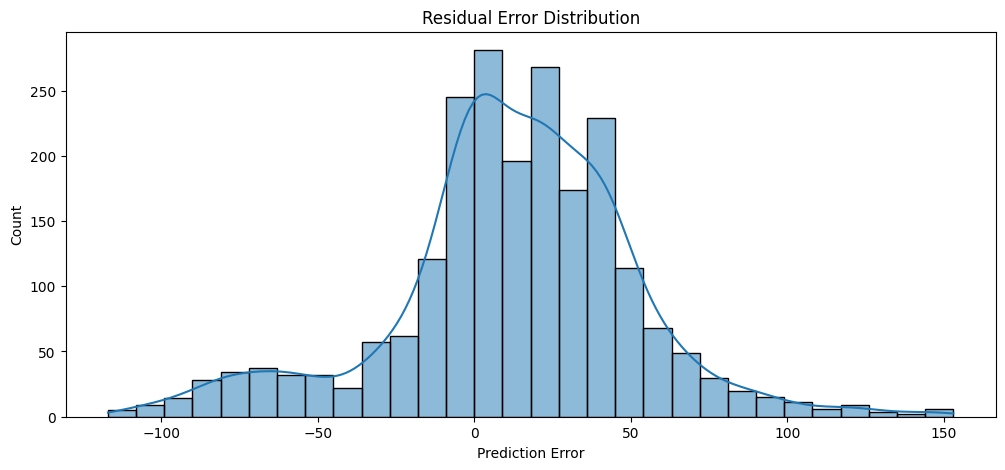

In [59]:
# Residual Analysis
residuals = y_test_actual.flatten() - gru_pred.flatten()

plt.figure(figsize=(12,5))

sns.histplot(residuals,
             bins=30,
             kde=True)

plt.title('Residual Error Distribution')
plt.xlabel('Prediction Error')
plt.show()

# Final Findings

In [ ]:
# Dataset & Preprocessing

# Used AI Financial Market dataset, sorted by Date, filled missing Event values
# Applied MinMaxScaler to scale data between 0-1 range
# Sequence length set to 60, with 80% train and 20% test split

# Target Variable Selection
# Initially tried Stock_Impact_% — resulted in negative R², no temporal pattern found
# Correlation heatmap confirmed near-zero correlation of Stock Impact with all other features
# Switched to AI_Revenue_USD_Mn — showed stable sequential behavior suitable for time series

# Model Performance

# Simple RNN — R²: 0.093 — unable to capture long-term dependencies, weakest model
# LSTM — R²: 0.254 — better than RNN, moderate performance
# GRU — R²: 0.492 — best performer, faster and more accurate than LSTM

# Hyperparameter Tuning

# Increased epochs from 20 → 50 — noticeable improvement in R² across all models
# Increased sequence length from 30 → 60 — more historical context improved predictions
# Tested 2 features (R&D + Revenue) — caused redundancy due to 0.94 correlation, single feature performed better

# Conclusion

# GRU was the best model for this dataset
# R² above 0.5 was difficult to achieve due to synthetic nature of dataset
# RNN < LSTM < GRU performance trend was clearly demonstrated